LAB 6 - Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

In [ ]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [5]:
#Step 2: Load Dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)


In [7]:
#Step 3: Explore the Dataset (EDA)
print(X.head())
print(X.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [9]:
print(X.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [13]:
#Step 4: Check Missing Values
print(X.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [15]:
#Step 5: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
#Step 6: Standardize Data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [23]:
#Step 7: Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [27]:
#Step 8: KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [29]:
#Step 9: Evaluate Models
accuracy_score(y_test, lr_pred)

0.9736842105263158

In [31]:
precision_score(y_test, lr_pred)

0.9722222222222222

In [33]:
recall_score(y_test, lr_pred)

0.9859154929577465

In [35]:
f1_score(y_test, lr_pred)

0.9790209790209791

In [37]:
confusion_matrix(y_test, lr_pred)

array([[41,  2],
       [ 1, 70]], dtype=int64)

In [43]:
#Step 10: Create Evaluation Function

def evaluate(name, y_true, y_pred):
    print("\n", name)

    print("Accuracy :", accuracy_score(y_true, y_pred))

    print("Precision:", precision_score(y_true, y_pred))

    print("Recall   :", recall_score(y_true, y_pred))

    print("F1 Score :", f1_score(y_true, y_pred))

    print("Confusion Matrix")

    print(confusion_matrix(y_true, y_pred))


evaluate("Logistic Regression", y_test, lr_pred)

evaluate("KNN", y_test, knn_pred)


 Logistic Regression
Accuracy : 0.9736842105263158
Precision: 0.9722222222222222
Recall   : 0.9859154929577465
F1 Score : 0.9790209790209791
Confusion Matrix
[[41  2]
 [ 1 70]]

 KNN
Accuracy : 0.9473684210526315
Precision: 0.9577464788732394
Recall   : 0.9577464788732394
F1 Score : 0.9577464788732394
Confusion Matrix
[[40  3]
 [ 3 68]]


In [45]:
# Step 11: Comparison Table

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, knn_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, knn_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, knn_pred)
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021
1                  KNN  0.947368   0.957746  0.957746  0.957746


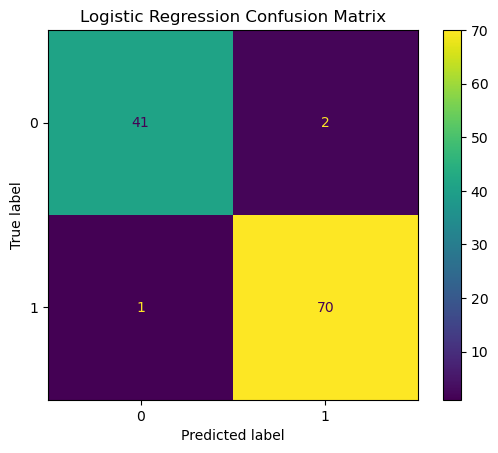

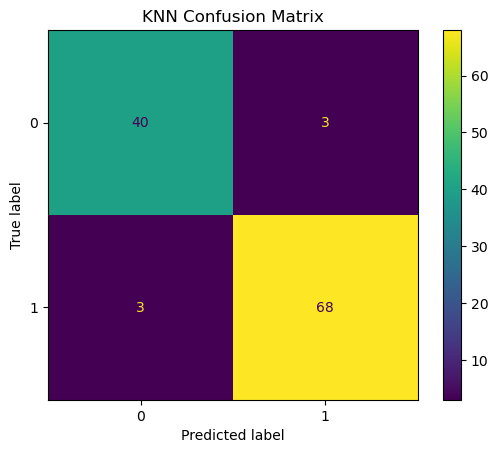

In [47]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.title("KNN Confusion Matrix")
plt.show()

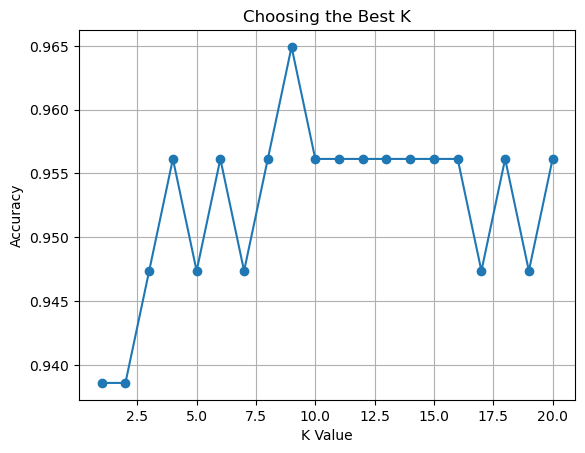

In [49]:
# Different K Values

accuracy = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    accuracy.append(accuracy_score(y_test, pred))

plt.plot(range(1,21), accuracy, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Choosing the Best K")
plt.grid(True)
plt.show()


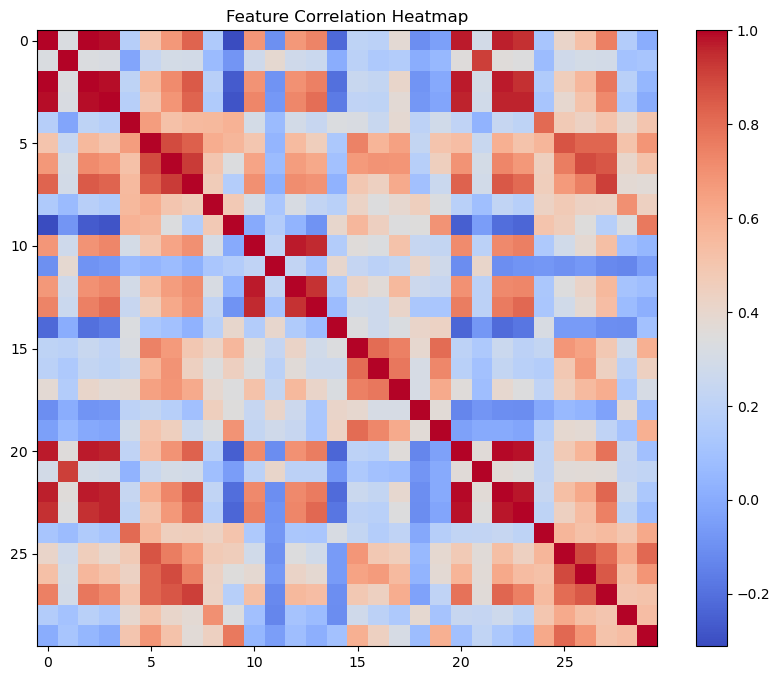

In [51]:
#heatmap
import matplotlib.pyplot as plt

corr = X.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#Step 12: Interpretation
#Logistic Regression achieved slightly higher accuracy,
#precision, recall, and F1 score compared to KNN.
#Logistic Regression is the preferred classifier for this dataset.